In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pycirclize import Circos

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,
    'axes.titlesize': 7,
    'axes.labelsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.titlesize': 7,
    'figure.dpi': 200,
    'axes.linewidth': 0.7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

In [2]:
# Load data
df_plot = pd.read_csv('data/DD_denovo.RDH_distribution.tsv', sep='\t')
df_plot['pos'] = df_plot.apply(
    lambda x: x['description'].lstrip(x['family'])[1:], axis=1
).astype(int) + 1

# HistMTR
mtr_df = pd.read_csv(
    '../Fig3/data/cRDH.HistMTR.obs_RGC.pred_MuRaL.tsv', sep='\t'
)

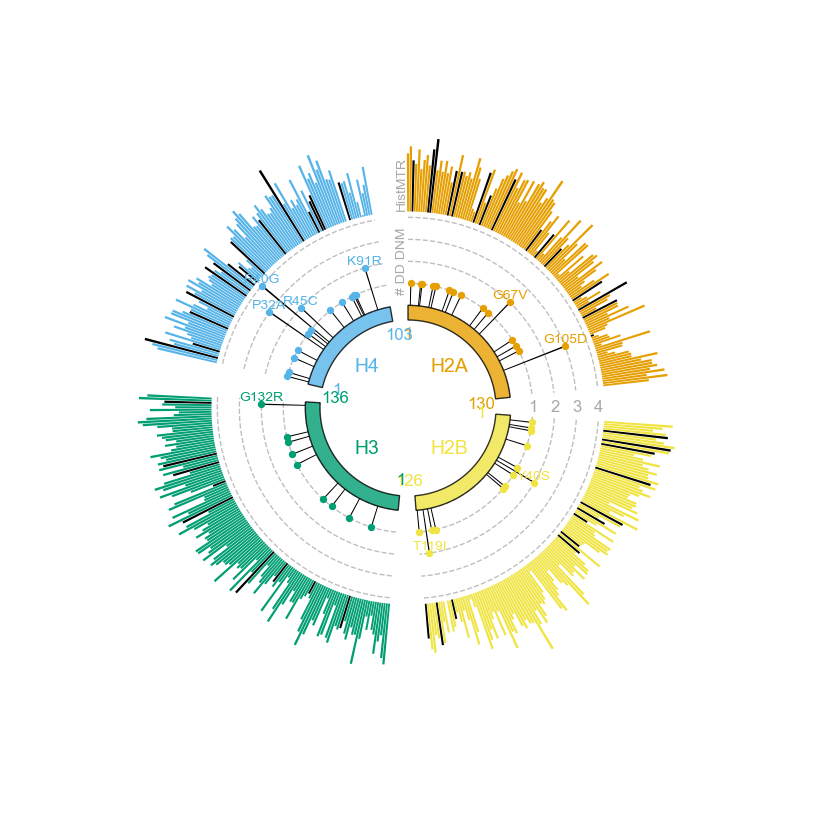

In [3]:
gene_colors = {
    "H2A": "#E69F00",
    "H2B": "#F0E442",
    "H3": "#009E73",
    "H4": "#56B4E9",
}

fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111, polar=True)

# Prepare sectors for the Circos plot
sectors = {'H2A': 130, 'H2B': 126, 'H3': 136, 'H4': 103}

# Create a Circos object with sectors
circos = Circos(sectors, space=10)
accumative_length = 0
total_length = sum(sectors.values()) + 10 * len(sectors)

for idx, sector in enumerate(circos.sectors):

    gene_df = df_plot[df_plot["family"] == sector.name]

    # Track name and length annotate
    circos.text(
        text=sector.name,
        deg=list(range(45, 360, 90))[idx],
        r=20,
        size=7,
        color=gene_colors[sector.name],
        ha="center",
        va="center",
    )

    ss_length = accumative_length + 10 * idx
    ed_length = ss_length + sectors[sector.name]

    circos.text(
        text="1",
        deg=ss_length / total_length * 360,
        r=25,
        size=6,
        color=gene_colors[sector.name],
        ha="center",
        va="center",
    )
    circos.text(
        text=str(sectors[sector.name]),
        deg=ed_length / total_length * 360,
        r=25,
        size=6,
        color=gene_colors[sector.name],
        ha="center",
        va="center",
    )

    # Track for amino acid sequence
    track_seq = sector.add_track((30, 35))
    track_seq.axis(fc=gene_colors[sector.name], alpha=0.8)

    # Track for DD patient DNM count
    pos_DD_dnm = gene_df["pos"].values
    count_DD_dnm = gene_df["#DD DNMs"].values

    track_dnmcount = sector.add_track((35, 65))
    track_dnmcount.bar(
        list(pos_DD_dnm),
        list(count_DD_dnm),
        color="black",
        vmin=0,
        vmax=4,
    )
    if sector.name == "H2A":

        for i in range(1, 5):
            circos.text(
                text=str(i),
                deg=90,
                r=35 + i * 30 / 4,
                size=6,
                color="darkgray",
            )
        circos.text(
            text="# DD DNM",
            deg=0,
            r=(35 + 65) / 2,
            size=5,
            color="darkgray",
            ha="right",
            va="center",
            rotation=90,
        )
        circos.text(
            text="HistMTR",
            deg=0,
            r=67,
            size=5,
            color="darkgray",
            ha="right",
            va="bottom",
            rotation=90,
        )

    track_dnmcount.scatter(
        list(pos_DD_dnm),
        list(count_DD_dnm),
        fc=gene_colors[sector.name],
        vmax=4,
        s=7,
    )
    track_dnmcount.grid(y_grid_num=5, ls="dashed")

    ## Annotate mutation information for count > 2
    gene_df_anno = gene_df[gene_df["#DD DNMs"] >= 2]
    for _, row in gene_df_anno.iterrows():
        ref_aa = row["description"].replace(row["family"], "")
        alt_aa_set = set()

        for mut in row["DD DNMs"].split(";"):
            if not mut:
                continue

            alt_aa = mut.split(":")[-1]
            alt_aa_set.add(alt_aa)

        alt_aa = "/".join(sorted(list(alt_aa_set)))
        anno_text = ref_aa + alt_aa

        track_dnmcount.text(
            x=row["pos"],
            text=anno_text.strip("/"),
            r=35 + row["#DD DNMs"] * 30 / 4,
            size=5,
            adjust_rotation=False,
            color=gene_colors[sector.name],
            ha="center",
            va="bottom",
        )

    # Track for MTR visualization
    track_mtr = sector.add_track((67, 97))

    mtr_df_family = mtr_df[mtr_df["family"] == sector.name]
    gene_df_with_dddnm = mtr_df_family[
        mtr_df_family['pos'].isin(pos_DD_dnm)
    ]
    gene_df_without_dddnm = mtr_df_family[
        ~mtr_df_family['pos'].isin(pos_DD_dnm)
    ]

    ## For positions with DD DNMs, use barplot with black border
    track_mtr.bar(
        list(gene_df_with_dddnm["pos"]),
        list(gene_df_with_dddnm["HistMTR"]),
        vmin=0,
        vmax=1.4,
        fc="black",
    )
    ## For positions without DD DNMs, use simple barplot
    track_mtr.bar(
        list(gene_df_without_dddnm["pos"]),
        list(gene_df_without_dddnm["HistMTR"]),
        vmin=0,
        vmax=1.4,
        fc=gene_colors[sector.name],
    )
    accumative_length += sectors[sector.name]

fig = circos.plotfig(ax=ax)